## MNIST Dataset


The MNIST database of handwritten digits is a well-known database comprised of
70,000 images of handwritten digits (0-9) split into 60,000 training images and 10,000 test images.
Each image is a 28x28 grayscale image.

In [1]:
# Load the dataset using scikit-learn
from sklearn.datasets import fetch_openml

# load the data
mnist = fetch_openml('mnist_784')

**Exercise:** Check the shape of the data and target arrays in `mnist`. What do these shapes tell you about the dataset?

## Data Exploration

Explore the dataset to understand its structure.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Get the data and the labels
X, y = mnist["data"], mnist["target"]

# Convert the labels to integers
y = y.astype(np.uint8)

The label of the image at 19768 is: 1



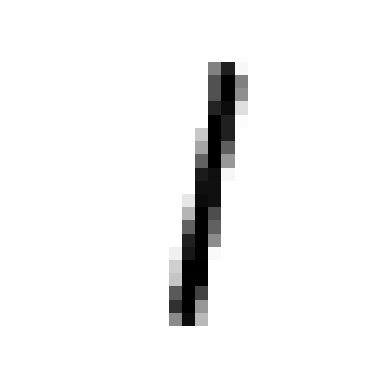

In [3]:

# Display the image from a random index
random_index = np.random.randint(0, len(X))
some_digit = X.iloc[random_index]
some_label = y.iloc[random_index]

# Display the image and the label
print(f"The label of the image at {random_index} is: {some_label}\n")
some_digit_image = some_digit.values.reshape(28, 28)
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

**Exercise:** Display five different images from the dataset along with their labels. What variations do you observe among different samples of the same digit?

In [4]:
# Display five different images from the dataset along with their labels
### Add your code here ###

## Data Processing

### Splitting the data

In [5]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

In [6]:
# Scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale the training data
X_train = scaler.fit_transform(X_train.astype(np.float64))

# Scale the test data
X_test = scaler.transform(X_test.astype(np.float64))

**Exercise:** Why do we scale the data? What could happen if we do not scale features in a neural network?

## Build a Neural Network with Scikit-learn

In [7]:
from sklearn.neural_network import MLPClassifier

# Initialize the neural network
mlp = MLPClassifier(hidden_layer_sizes=(100,), activation = 'relu',
                    solver='adam', max_iter=100, random_state=42)

**Exercise:** Modify the `hidden_layer_sizes` parameter to add an additional hidden layer with 50 neurons. How does this change the network architecture?

In [ ]:
### Add your code here ###

In [8]:
# Train the neural network
# This will take some time
mlp.fit(X_train, y_train)

MLPClassifier(max_iter=100, random_state=42)

**Exercise:** Monitor the loss curve during training by setting `verbose=True` and `early_stopping=True` in the `MLPClassifier`. What do you observe about the loss of epochs?

## Evaluate the Model

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Make predictions on the test set
y_pred = mlp.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy: .4f}")

Accuracy:  0.9712


**Exercise:** Compute the confusion matrix for the test predictions. Which digits are most commonly misclassified?

In [ ]:
# Computer the confusion matrix
### Add your code here ###

## Making Predictions

In [10]:
# Choose some test samples
num_samples = 5
random_indices = np.random.choice(len(X_test), num_samples, replace=False)
sample_images = X_test[random_indices]
sample_labels = y_test.iloc[random_indices]

sample_images_scaled = scaler.transform(sample_images.astype(np.float64))

# Make predictions on the sample images
sample_predictions = mlp.predict(sample_images_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


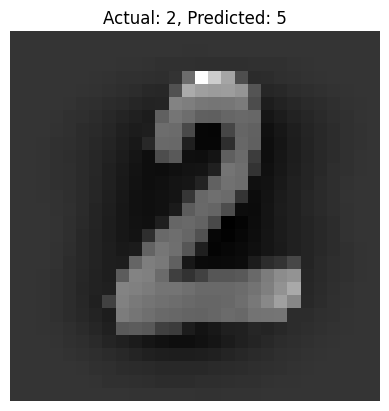

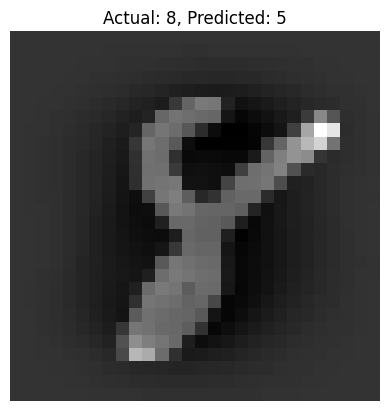

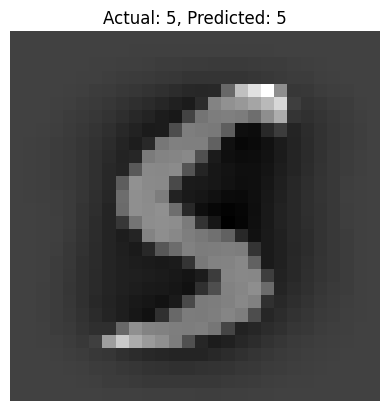

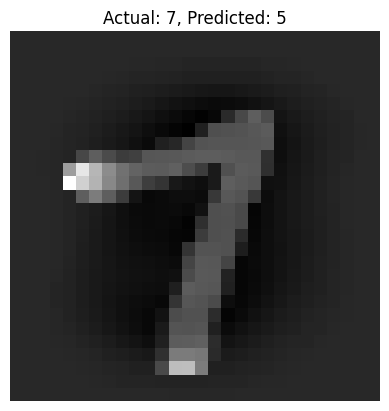

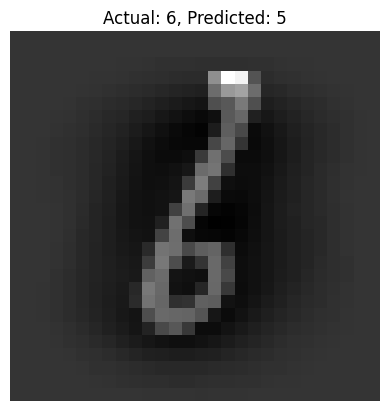

In [11]:
# Display the images with predictions and actual labels
for i in range(num_samples):
    image = sample_images[i].reshape(28, 28)
    plt.imshow(image, cmap='gray')
    plt.title(f"Actual: {sample_labels.iloc[i]}, Predicted: {sample_predictions[i]}")
    plt.axis('off')
    plt.show()


**Exercise:** Select 10 random test samples where the model made incorrect predictions. Display the images along with their actual and predicted labels. Do you see any patterns?

Exercise: You will create your own handwritten digits, test them using your trained MNIST model, and analyze cases where the model makes incorrect predictions.

***Instructions***
1. Create Your Own Test Samples

Write the digits 0–9 on a blank sheet of paper.

Make them large and clear (similar to MNIST style: thick strokes, centered).

Take a photo of your handwritten digits using your phone.

Preprocess the image to match MNIST requirements:

Convert to grayscale

Resize to 28 × 28

Invert colors if necessary (MNIST digits are white on black)

Normalize pixel values

2. Run Your Trained MNIST Model

Load your trained neural network.

Run inference on your preprocessed handwritten digit images.

Record the model’s predictions for each of your digits.